In [1]:
import sys
sys.path.append('..')

In [2]:
import numpy as np
import pandas as pd
from os.path import join as pjoin
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

from utils.misc import load_config

/home/nasim/anaconda3/envs/ML/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import patchify as pf

In [4]:
root = '../data/processed'

In [5]:
xPath = pjoin(root, 'X.h5')
yPath = pjoin(root, 'Y.h5')

In [6]:
X = pd.read_hdf(xPath)
Y = pd.read_hdf(yPath)

<Axes: >

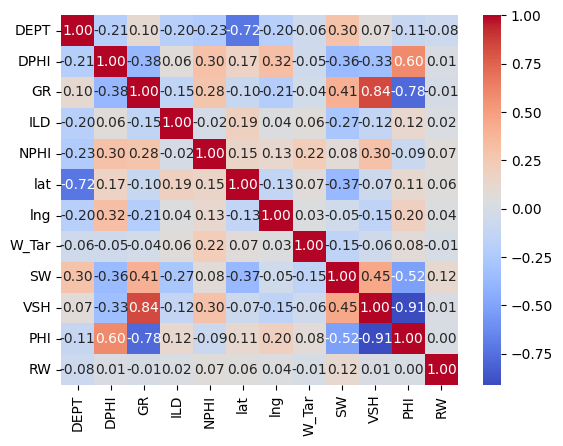

In [10]:
import seaborn as sns
sns.heatmap(X.drop('UWI', axis=1).corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [ ]:
X.UWI.unique().shape

In [ ]:
key, val = np.unique(Y, return_counts=True)

In [ ]:
data_config = load_config('..', 'config/data', 'base.yaml')

In [ ]:
lithology_classes = data_config['lithology_classes']
lithology_classes = {v: k for k, v in lithology_classes.items()}

In [ ]:
plt.bar([lithology_classes[k] for k in key], val)
plt.xticks(rotation=90)
plt.show()

In [ ]:
well_names = X.UWI.unique()

In [ ]:
# X.drop(['ILD'], axis=1, inplace=True)

In [ ]:
lat_min, lat_max = X.lat.min(), X.lat.max()
lng_min, lng_max = X.lng.min(), X.lng.max()
depth_min, depth_max = X.DEPT.min(), X.DEPT.max()

In [ ]:
X.lat = (X.lat - lat_min) / (lat_max - lat_min)
X.lng = (X.lng - lng_min) / (lng_max - lng_min)
X.DEPT = (X.DEPT - depth_min) / (depth_max - depth_min)

In [ ]:
scaler = StandardScaler()
X.ILD = scaler.fit_transform(X.ILD.values.reshape(-1, 1))

In [ ]:
scaler_gr = StandardScaler()
X.GR = scaler_gr.fit_transform(X.GR.values.reshape(-1, 1))

scaler_nphi = StandardScaler()
X.NPHI = scaler_nphi.fit_transform(X.NPHI.values.reshape(-1, 1))

scaler_dphi = StandardScaler()
X.DPHI = scaler_dphi.fit_transform(X.DPHI.values.reshape(-1, 1))

In [ ]:
well_names = X['UWI'].unique()

In [ ]:
import random
from tqdm import tqdm

In [ ]:
# removing all the wells that have all the lithology classes
problematic_well = [i for i in tqdm(list(well_names)) if len(Y[X.UWI == i].unique()) == 7]
well_names = list(well_names)
for well in problematic_well:
    well_names.remove(well)
print(len(problematic_well), len(well_names))

Y = Y[~X.UWI.isin(problematic_well)]
X = X[~X.UWI.isin(problematic_well)]

In [ ]:
# removing all the wells that have less than 150 samples or patch_size
problematic_well = [i for i in tqdm(list(well_names)) if len(X[X.UWI == i]) < 150]

for well in problematic_well:
    well_names.remove(well)

print(len(problematic_well), len(well_names))

Y = Y[~X.UWI.isin(problematic_well)]
X = X[~X.UWI.isin(problematic_well)]

In [ ]:
train_well_candidate = [i for i in tqdm(list(well_names)) if len(Y[X.UWI == i].unique()) == 6]
train_well = random.sample(train_well_candidate, 1)[0]
well_names.remove(train_well)
test_well = random.sample(well_names, 1)[0]
well_names.remove(test_well)

In [ ]:
X_train = X[X.UWI == train_well]
y_train = Y[X.UWI == train_well]

X_test = X[X.UWI == test_well]
y_test = Y[X.UWI == test_well]

In [ ]:
ulabelled_wells = well_names

In [ ]:
X_unlabelled = [X[X.UWI == i] for i in tqdm(ulabelled_wells)]
y_unlabelled = [Y[X.UWI == i] for i in tqdm(ulabelled_wells)]

In [ ]:
# X.drop('UWI', axis = 1, inplace = True)

In [ ]:
# undefined = X[Y==0]
# X = X[Y!=0]
# Y = Y[Y!=0]

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.9999, random_state=42)
# X_unlabelled, X_test, y_unlabelled, y_test = train_test_split(X_test, y_test, test_size=0.2, random_state=42)
# X_train = X_train.to_numpy()
# X_test = X_test.to_numpy()
# y_train = y_train.to_numpy()
# y_test = y_test.to_numpy()
# X_unlabelled = X_unlabelled.to_numpy()
# y_unlabelled = y_unlabelled.to_numpy()

In [ ]:
len(X_train), len(X_test), len(X_unlabelled)

# Torch

In [ ]:
from tqdm import tqdm

In [ ]:
# patch_size = 150
# stride = 75
# num_features = X.shape[1] - 1

# x_patches, y_patches = [], []
# for well in tqdm(well_names):
#     well_x = X[X.UWI == well]
#     well_y = Y[well_x.index]
#     well_x = well_x.drop(['UWI'], axis=1)
#     if well_x.shape[0] >= patch_size:
#         well_x_patches = pf.patchify(well_x.values, (patch_size, num_features), step=stride)
#         well_x_patches = well_x_patches.squeeze()

#         well_y_patches = pf.patchify(well_y.values, patch_size, step=stride)
#         well_y_patches = well_y_patches.squeeze()

#         if well_x_patches.ndim == 3:
#             for i, j in zip(well_x_patches, well_y_patches):
#                 x_patches.append(i)
#                 y_patches.append(j)
#         else:
#             x_patches.append(well_x_patches)
#             y_patches.append(well_y_patches)
# num_classes = len(np.unique(y_patches))

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_patches, y_patches, test_size=0.2, random_state=42)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
# Convert the data to PyTorch tensors
X_train = torch.tensor(x_train).float()
y_train = torch.tensor(y_train)
X_val = torch.tensor(x_val).float()
y_val = torch.tensor(y_val)

In [ ]:
import torch
from torch import nn

from einops import rearrange
from einops.layers.torch import Rearrange

#create position embedding sin/cos for each patch of size 100x7
def posemb_sincos_2d(x):
    # x is of shape (batch_size, seq_len, dim)
    seq_len = x.shape[1]
    dim = x.shape[2]
    pos = torch.arange(seq_len)[:, None]
    i = torch.arange(dim)[None, :]
    angle_rates = 1 / torch.pow(10000, (2 * (i // 2)) / dim)
    angle_rads = pos * angle_rates
    # apply sin to even index in the array
    angle_rads[:, 0::2] = torch.sin(angle_rads[:, 0::2])
    # apply cos to odd index in the array
    angle_rads[:, 1::2] = torch.cos(angle_rads[:, 1::2])
    pos_emb = angle_rads[None, :, :]

    return pos_emb

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim),
        )
    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64):
        super().__init__()
        inner_dim = dim_head *  heads
        self.heads = heads
        self.scale = dim_head ** -0.5
        self.norm = nn.LayerNorm(dim)

        self.attend = nn.Softmax(dim = -1)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)
        self.to_out = nn.Linear(inner_dim, dim, bias = False)

    def forward(self, x):
        x = self.norm(x)

        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Attention(dim, heads = heads, dim_head = dim_head),
                FeedForward(dim, mlp_dim)
            ]))
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x

class SimpleViT(nn.Module):
    def __init__(self, num_classes, dim, depth, heads, mlp_dim, num_features, patch_size, channels = 1, dim_head = 64):
        super().__init__()
        image_height, image_width = patch_size, num_features
        patch_height, patch_width = 1,num_features

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b (h p1) (w p2) -> b h w (p1 p2)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim)

        self.to_latent = nn.Identity()
        self.linear_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):
        *_, h, w, dtype = *img.shape, img.dtype

        x = self.to_patch_embedding(img)
        pe = posemb_sincos_2d(x).cuda()
        x = rearrange(x, 'b ... d -> b (...) d') + pe

        x = self.transformer(x)
        # x = x.mean(dim = 1)

        x = self.to_latent(x)
        return self.linear_head(x)

In [ ]:
# Define the Transformer model
class TransformerModel(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=64, num_layers=2, num_heads=7):
        super(TransformerModel, self).__init__()
        self.encoder = nn.TransformerEncoder(nn.TransformerEncoderLayer(input_size, 
                                                                        num_heads, 
                                                                        hidden_size, 
                                                                        dropout=0.1,
                                                                        batch_first = True), num_layers)
        self.decoder = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
from torch import nn

class ANN(nn.Module):
    def __init__(self, input_size, output_size, hidden_layer_sizes=[8, 4, 2]):
        super(ANN, self).__init__()

        layers = []
        layer_sizes = [input_size] + hidden_layer_sizes + [output_size]

        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < len(layer_sizes) - 2:
                layers.append(nn.ReLU())

        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        x = self.encoder(x)
        return x

In [ ]:
# class ANN(nn.Module):
#     def __init__(self, input_size, output_size, hidden_size=64, num_layers=2):
#         super(ANN, self).__init__()
#         self.encoder = nn.Sequential(
#             nn.Linear(input_size, hidden_size),
#             nn.ReLU(),
#             nn.Linear(hidden_size, output_size)
#         )

#     def forward(self, x):
#         x = self.encoder(x)
#         return x

In [ ]:
#set random seed
torch.manual_seed(42)
np.random.seed(42)
# Create an instance of the Transformer model
# model = TransformerModel(input_size=7, output_size=7, hidden_size=256, num_layers=4, num_heads=1)
# model = SimpleViT(num_classes=7, dim = 32, depth = 1, heads=4, mlp_dim=256, num_features=num_features, patch_size=150)
model = ANN(input_size=7, output_size=7, hidden_size=64, num_layers=2)
model.cuda()

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100

In [ ]:
from tqdm import tqdm

In [ ]:
# Create a DataLoader for efficient batching
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_loss = np.inf

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    val_loss = 0.0
    train_correct = 0
    val_correct = 0


    for batch_inputs, batch_labels in tqdm(train_loader, total=len(train_loader), desc=f"Train - Epoch {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_inputs.cuda())
        batch_labels = batch_labels.long().cuda()
        outputs_ = rearrange(outputs, 'b n d -> b d n')
        loss = criterion(outputs_, batch_labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Calculate training accuracy
        predicted = torch.argmax(nn.Softmax(dim = -1)(outputs), dim=-1)
        train_correct += (((batch_labels == predicted).sum(-1).float().mean().item())/batch_inputs.shape[1])*100

        train_loss += loss.item()

    # Calculate average training loss and accuracy for the epoch
    train_loss /= len(train_loader)
    train_accuracy = train_correct / len(train_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Evaluate on the validation set
    model.eval()
    for batch_inputs_val, batch_labels_val in tqdm(val_loader, total=len(val_loader), desc=f"Val - Epoch {epoch+1}/{num_epochs}"):
        val_outputs = model(batch_inputs_val.cuda())
        batch_labels_val = batch_labels_val.long().cuda()
        val_outputs_ = rearrange(val_outputs, 'b n d -> b d n')
        loss_val = criterion(val_outputs_, batch_labels_val)

        val_predicted = torch.argmax(nn.Softmax(dim = -1)(val_outputs), dim=-1)
        val_correct += (((val_predicted == batch_labels_val).sum(-1).float().mean().item())/batch_inputs_val.shape[1])*100

        val_loss += loss_val.item()

    val_loss /= len(val_loader)
    val_accuracy = val_correct / len(val_loader)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Print the progress for the current epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: \
          {train_accuracy:.2f}%, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_epoch = epoch
        # torch.save(model.state_dict(), 'best_model.pth')

    if epoch - best_epoch > 10:
        print("Early stopping")
        break
    
from matplotlib import pyplot as plt
_, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(train_losses, label='train loss')
ax[0].plot(val_losses, label='val loss')

ax[1].plot(train_accuracies, label='train accuracy')
ax[1].plot(val_accuracies, label='val accuracy')

ax[0].legend()
ax[1].legend()

plt.show()

In [ ]:
idx = 20
_ = plt.figure(figsize=(4, 12))
plt.plot(batch_labels_val[idx].cpu().numpy(), list(range(0, batch_inputs_val.shape[1])), label='true')
plt.plot(val_predicted[idx].cpu().numpy(), list(range(0, batch_inputs_val.shape[1])), label='predicted')
plt.legend()
plt.show()

In [ ]:
[lithology_classes[i] for i in lithology_classes]

In [ ]:
lithology_classes = {
    0: 'Undefined',
    1: 'Sand',
    2: 'ShalySand',
    3: 'SandyShale',
    4: 'Shale',
    5: 'Coal',
    6: 'CementedSand'
}

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

cmap = plt.get_cmap('viridis')
levels = MaxNLocator(nbins=7).tick_values(0, 7)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors

In [ ]:
idx = np.random.randint(len(batch_inputs_val))
class_color = ['black', 'yellow', 'red', 'green', 'blue', 'purple', 'grey']
labels = [lithology_classes[i] for i in range(0, 7)]
cmap_facies = colors.ListedColormap(class_color[0:len(class_color)], 'indexed')

rescaled_depth = (batch_inputs_val[idx, :, 0] * (depth_max - depth_min) + depth_min)
gr = scaler_gr.inverse_transform(batch_inputs_val[idx, :, 2].cpu().numpy().reshape(-1, 1)).reshape(-1)
nphi = scaler_nphi.inverse_transform(batch_inputs_val[idx, :, 3].cpu().numpy().reshape(-1, 1)).reshape(-1)
dphi = scaler_dphi.inverse_transform(batch_inputs_val[idx, :, 1].cpu().numpy().reshape(-1, 1)).reshape(-1)

_, ax = plt.subplots(1, 5, figsize=(10, 15), sharey=True)
ax[0].plot(gr, list(range(0, batch_inputs_val.shape[1])), label='GR')
ax[1].plot(nphi, list(range(0, batch_inputs_val.shape[1])), label='NPHI')
ax[2].plot(dphi, list(range(0, batch_inputs_val.shape[1])), label='DPHI')


ax[3].imshow(np.repeat(batch_labels_val[idx].cpu().numpy().reshape(1, -1), 10, axis=0).T, cmap=cmap_facies, vmin=0, vmax=7)
im = ax[4].imshow(np.repeat(val_predicted[idx].cpu().numpy().reshape(1, -1), 10, axis=0).T, 
                  cmap=cmap_facies, vmin=0, vmax=7)

ax[0].set_yticks(list(range(0, batch_inputs_val.shape[1], 10)), rescaled_depth[::10].cpu().numpy().round(2))

ax[0].set_title('GR')
ax[1].set_title('NPHI')
ax[2].set_title('DPHI')
ax[3].set_title('True')
ax[4].set_title('Predicted')

ax[0].set_ylim(0, len(rescaled_depth) - 1)

ax[0].invert_yaxis()
ax[1].invert_yaxis()
ax[2].invert_yaxis()




divider = make_axes_locatable(ax[-1])
cax = divider.append_axes("right", size="20%", pad=0.05)
cbar=plt.colorbar(im, cax=cax)

cmap_min = 0
cmap_max = 7
cbar.set_ticks(np.linspace(0+0.4, 7 - 0.2, 7))
cbar.set_ticklabels(labels, rotation=90)
plt.show()

In [ ]:
batch_labels_val[idx].cpu().numpy().reshape(1, -1).shape

# 1. Random Forest; Data As It Is, No Scaling done

In [ ]:
X

In [ ]:
classifier = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs = -1, verbose = 1)
classifier.fit(X_train, y_train)
print('Accuracy Train: ', accuracy_score(y_train, classifier.predict(X_train)))
print('Accuracy Test: ', accuracy_score(y_test, classifier.predict(X_test)))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
cm_test = confusion_matrix(y_test, classifier.predict(X_test))
cm_test = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]

cm_train = confusion_matrix(y_train, classifier.predict(X_train))
cm_train = cm_train.astype('float') / cm_train.sum(axis=1)[:, np.newaxis]

In [ ]:
np.unique(classifier.predict(undefined), return_counts=True)

In [ ]:
def plot_confusion_matrix(train, val, lithology_classes):
    _, ax = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(train, annot=True, 
                fmt='.2f', 
                xticklabels=lithology_classes.keys(), 
                yticklabels=lithology_classes.keys(), 
                ax = ax[0])
    sns.heatmap(val, annot=True, 
                fmt='.2f', 
                xticklabels=lithology_classes.keys(), 
                yticklabels=lithology_classes.keys(), 
                ax = ax[1])
    ax[0].set_title('Train')
    ax[1].set_title('Validation')
    ax[0].set_ylabel('True label')
    ax[0].set_xlabel('Predicted label')
    ax[1].set_ylabel('True label')
    ax[1].set_xlabel('Predicted label')
    plt.show()

In [ ]:
plot_confusion_matrix(cm_train, cm_test, lithology_classes)

# 2. ANN; Data As It Is, No Scaling done

In [ ]:
X_train = X_train.drop('UWI', axis=1)
X_test = X_test.drop('UWI', axis=1)
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [ ]:
train_accuracies_over_time = []
test_accuracies_over_time = []
overall_accuracies_over_time = []

In [ ]:
classifier = MLPClassifier(hidden_layer_sizes=(6, 8, 16, 8, 7), random_state=44, learning_rate_init = 0.01, max_iter=1000)
classifier.fit(X_train, y_train)
train_acc = accuracy_score(y_train, classifier.predict(X_train))
test_acc = accuracy_score(y_test, classifier.predict(X_test))
X = X.drop("UWI", axis=1)
X = X.values
Y = Y.values
overall_acc = accuracy_score(Y, classifier.predict(X))
print('Accuracy Train: ', train_acc)
print('Accuracy Test: ', test_acc)
print('Accuracy Overall: ', overall_acc)
train_accuracies_over_time.append(overall_acc)
test_accuracies_over_time.append(test_acc)
overall_accuracies_over_time.append(overall_acc)

# 2.1 Active Learning

In [ ]:
# Active learning loop
num_queries = 100  # Number of queries to make
query_batch_size = 1  # Number of samples to query in each iteration
total_training_wells = 1
for _ in range(num_queries):
    total_training_wells += query_batch_size
    well_uncertainties = []
    for unalbelled_well, unlabelled_well_gt in zip(X_unlabelled, y_unlabelled):
        unalbelled_well = unalbelled_well.drop('UWI', axis=1)
        unalbelled_well = unalbelled_well.values
        unlabelled_well_gt = unlabelled_well_gt.values

        # Predict probabilities for the unlabeled data
        probas = classifier.predict_proba(unalbelled_well)

        # Calculate uncertainty scores using entropy
        uncertainties = -np.sum(probas * np.log2(probas + 1e-10), axis=1)
        well_uncertainties.append(uncertainties.mean())
    
    # Select the top uncertain samples to query
    query_indices = np.argsort(well_uncertainties)[-query_batch_size:]
    queried_samples = X_unlabelled[query_indices[0]]
    queried_labels = y_unlabelled[query_indices[0]]

    queried_samples = queried_samples.drop('UWI', axis=1)
    queried_samples = queried_samples.values
    queried_labels = queried_labels.values

    
    # Add queried samples to the labeled set
    X_train = np.vstack((X_train, queried_samples))
    y_train = np.concatenate((y_train, queried_labels))
    
    # Remove queried samples from the unlabeled set
    del X_unlabelled[query_indices[0]]
    del y_unlabelled[query_indices[0]]
    
    # Retrain the classifier on the updated labeled data
    classifier.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, classifier.predict(X_train))
    test_acc = accuracy_score(y_test, classifier.predict(X_test))
    overall_acc = accuracy_score(Y, classifier.predict(X))
    print('Accuracy Train: ', train_acc)
    print('Accuracy Test: ', test_acc)
    print('Accuracy Overall: ', overall_acc)
    print(len(X_train), len(X_test), len(X_unlabelled), total_training_wells)
    print('='*120)

    train_accuracies_over_time.append(train_acc)
    test_accuracies_over_time.append(test_acc)
    overall_accuracies_over_time.append(overall_acc)

In [ ]:
def curve_smoothing(curve, smoothing_factor = 0.9):
    smoothed_curve = [curve[0]]
    for val in curve[1:]:
        smoothed_value = smoothed_curve[-1] * smoothing_factor + val * (1 - smoothing_factor)
        smoothed_curve.append(smoothed_value)
    return smoothed_curve

In [ ]:
smoothing_factor = 0.8
plt.plot(curve_smoothing(train_accuracies_over_time, smoothing_factor), label='train')
plt.plot(curve_smoothing(test_accuracies_over_time, smoothing_factor), label = 'test')
plt.plot(curve_smoothing(overall_accuracies_over_time, smoothing_factor), label = 'overall')
plt.legend()

In [ ]:
np.argsort(uncertainties)

In [ ]:
query_indices

# 2. ANN; Data As It Is, Min Max Scaler; NPHI, DPHI excluded from scaling

In [ ]:
X = pd.read_hdf(xPath)
Y = pd.read_hdf(yPath)

In [ ]:
X.lat = (X.lat - X.lat.min()) / (X.lat.max() - X.lat.min())
X.lng = (X.lng - X.lng.min()) / (X.lng.max() - X.lng.min())
X.DEPT = (X.DEPT - X.DEPT.min()) / (X.DEPT.max() - X.DEPT.min())

In [ ]:
X.ILD = (X.ILD - X.ILD.min()) / (X.ILD.max() - X.ILD.min())
X.GR = (X.GR - X.GR.min()) / (X.GR.max() - X.GR.min())

In [ ]:
x = X.values
y = Y.values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
classifier = MLPClassifier(hidden_layer_sizes=(100, ), random_state=42, verbose = 1)
classifier.fit(x_train, y_train)
print('Accuracy Train: ', accuracy_score(y_train, classifier.predict(x_train)))
print('Accuracy Test: ', accuracy_score(y_test, classifier.predict(x_test)))

# 2. ANN; Data As It Is, Min Max Scaler; NPHI, DPHI also scaling

In [ ]:
X = pd.read_hdf(xPath)
Y = pd.read_hdf(yPath)

In [ ]:
X.lat = (X.lat - X.lat.min()) / (X.lat.max() - X.lat.min())
X.lng = (X.lng - X.lng.min()) / (X.lng.max() - X.lng.min())
X.DEPT = (X.DEPT - X.DEPT.min()) / (X.DEPT.max() - X.DEPT.min())

In [ ]:
X.ILD = (X.ILD - X.ILD.min()) / (X.ILD.max() - X.ILD.min())
X.GR = (X.GR - X.GR.min()) / (X.GR.max() - X.GR.min())

In [ ]:
X.NPHI = (X.NPHI - X.NPHI.min()) / (X.NPHI.max() - X.NPHI.min())
X.DPHI = (X.DPHI - X.DPHI.min()) / (X.DPHI.max() - X.DPHI.min())

In [ ]:
x = X.values
y = Y.values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
classifier = MLPClassifier(hidden_layer_sizes=(100, ), random_state=42, verbose = 1)
classifier.fit(x_train, y_train)
print('Accuracy Train: ', accuracy_score(y_train, classifier.predict(x_train)))
print('Accuracy Test: ', accuracy_score(y_test, classifier.predict(x_test)))

# 2. ANN; Data As It Is, Standard Scaler, Depth, Lat, Long in MinMax

In [ ]:
X = pd.read_hdf(xPath)
Y = pd.read_hdf(yPath)

In [ ]:
X.lat = (X.lat - X.lat.min()) / (X.lat.max() - X.lat.min())
X.lng = (X.lng - X.lng.min()) / (X.lng.max() - X.lng.min())
X.DEPT = (X.DEPT - X.DEPT.min()) / (X.DEPT.max() - X.DEPT.min())

In [ ]:
scaler = StandardScaler()
X.ILD = scaler.fit_transform(X.ILD.values.reshape(-1, 1))

In [ ]:
scaler = StandardScaler()
X.GR = scaler.fit_transform(X.GR.values.reshape(-1, 1))

scaler = StandardScaler()
X.NPHI = scaler.fit_transform(X.NPHI.values.reshape(-1, 1))

scaler = StandardScaler()
X.DPHI = scaler.fit_transform(X.DPHI.values.reshape(-1, 1))

In [ ]:
x = X.values
y = Y.values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
classifier = MLPClassifier(hidden_layer_sizes=(100, ), random_state=42, verbose = 1)
classifier.fit(x_train, y_train)
print('Accuracy Train: ', accuracy_score(y_train, classifier.predict(x_train)))
print('Accuracy Test: ', accuracy_score(y_test, classifier.predict(x_test)))

# 2. ANN; Data As It Is, Standard Scaler

In [ ]:
X = pd.read_hdf(xPath)
Y = pd.read_hdf(yPath)

In [ ]:
scaler = StandardScaler()
X.ILD = scaler.fit_transform(X.ILD.values.reshape(-1, 1))

scaler = StandardScaler()
X.GR = scaler.fit_transform(X.GR.values.reshape(-1, 1))

scaler = StandardScaler()
X.NPHI = scaler.fit_transform(X.NPHI.values.reshape(-1, 1))

scaler = StandardScaler()
X.DPHI = scaler.fit_transform(X.DPHI.values.reshape(-1, 1))

scaler = StandardScaler()
X.lat = scaler.fit_transform(X.lat.values.reshape(-1, 1))

scaler = StandardScaler()
X.lng = scaler.fit_transform(X.lng.values.reshape(-1, 1))

scaler = StandardScaler()
X.DEPT = scaler.fit_transform(X.DEPT.values.reshape(-1, 1))

In [ ]:
x = X.values
y = Y.values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
classifier = MLPClassifier(hidden_layer_sizes=(100, ), random_state=42, verbose = 1)
classifier.fit(x_train, y_train)
print('Accuracy Train: ', accuracy_score(y_train, classifier.predict(x_train)))
print('Accuracy Test: ', accuracy_score(y_test, classifier.predict(x_test)))

In [ ]:
print(classification_report(y_train, classifier.predict(x_train)))

In [ ]:
print(classification_report(y_test, classifier.predict(x_test)))